# Trabajo Práctico 2 - Grupo 02

### Modelo XLM-RoBERTa-**Large** — Split limpio + EDA aug + Class weights (máxima potencia)

Integrantes:

*   Bermudez, Agustin
*   Calderón, Tiago
*   Gonzalez Pautaso, Mateo
*   Moreyra, Santiago
*   Nieves, Maylen

**Modelo:** `xlm-roberta-large` (560M parámetros, multilingüe, Meta AI) — el doble de capacidad que base.

**Dataset:** train original + EDA aug solo en fold de entrenamiento (split limpio, sin contaminación de val).

**Optimizaciones aplicadas (máxima potencia):**
1. **xlm-roberta-large**: 560M params vs 278M de base → representación más rica, especialmente en clases ambiguas.
2. **Class weights [1.0, 2.5, 1.0]**: penaliza 2.5× los errores en neutra (bottleneck crítico).
3. **max_length=256**: captura contexto completo de reseñas largas.
4. **Gradient accumulation steps=2**: batch efectivo=32 con batch físico=16 (VRAM).
5. **lr=1e-5**: tasa más conservadora, óptima para modelos grandes.
6. **Cosine LR scheduler**: descenso más suave, mejor convergencia final que decay lineal.
7. **warmup_ratio=0.15**: más warmup para estabilizar el modelo grande al inicio.
8. **epochs=5 + early stopping patience=2**: entrena hasta convergencia real.

**Hiperparámetros:** `lr=1e-5` | `epochs=5` | `max_length=256` | `batch=16` | `grad_accum=2` | `class_weights=[1.0, 2.5, 1.0]`

## 1. Setup

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
if torch.cuda.is_available():
    print("CUDA/ROCm disponible")
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("Sin GPU CUDA/ROCm — se usará CPU (entrenamiento lento)")

CUDA/ROCm disponible
GPU: AMD Radeon RX 9070 XT
VRAM: 17.1 GB


## 2. Imports y funciones auxiliares

In [2]:
import sys
sys.path.insert(0, "../../..")

import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
from pathlib import Path
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import f1_score, classification_report, confusion_matrix

from common.data_utils import get_split, SEED
from common.preprocessing import clean_minimal
from common.evaluation import evaluate

np.random.seed(SEED)
torch.manual_seed(SEED)

CLASS_NAMES = ["negativa", "neutra", "positiva"]
print("Imports OK")

Imports OK


## 3. Configuración

In [3]:
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_FP16      = torch.cuda.is_available()
MODEL_NAME    = "xlm-roberta-large"
MAX_LENGTH    = 256
BATCH_SIZE    = 16    # batch físico — limitado por VRAM del large
GRAD_ACCUM    = 2     # batch efectivo = BATCH_SIZE * GRAD_ACCUM = 32
NUM_EPOCHS    = 5
LR            = 1e-5  # más conservador para modelo grande
CLASS_WEIGHTS = [1.0, 2.5, 1.0]   # [neg, neu, pos] — neutra penalizada 2.5×
SAVE_NAME     = "red_neuronal_xlm_roberta_n13_large"

print(f"Device:          {DEVICE}")
print(f"fp16:            {USE_FP16}")
print(f"Modelo:          {MODEL_NAME}")
print(f"Config:          lr={LR} | epochs={NUM_EPOCHS} | max_length={MAX_LENGTH}")
print(f"Batch:           físico={BATCH_SIZE} | acumulación={GRAD_ACCUM} | efectivo={BATCH_SIZE*GRAD_ACCUM}")
print(f"Class weights:   {CLASS_WEIGHTS}")

Device:          cuda
fp16:            True
Modelo:          xlm-roberta-large
Config:          lr=1e-05 | epochs=5 | max_length=256
Batch:           físico=16 | acumulación=2 | efectivo=32
Class weights:   [1.0, 2.5, 1.0]


## 4. Carga de datos con split limpio

### Estrategia (corrige el leakage de versiones anteriores)

```
train.csv (51,000 reales)
    ↓ get_split()
    ├── train_orig (40,800 reales) ──┐
    │                                │
    └── val_clean (10,200 reales)    │ + EDA aug (solo clases muestreadas del train)
                                     ↓
                               df_train_final (~54,000)
```

El val set contiene **únicamente** muestras reales de `train.csv`.

In [4]:
# 1. Cargar datos originales
df_original = pd.read_csv("../../../data/train.csv")
test_df     = pd.read_csv("../../../data/test.csv")
original_ids = set(df_original["id"])

print(f"Dataset original: {len(df_original):,} filas")
print(f"Distribución:\n{df_original['label'].value_counts().sort_index()}")

# 2. Split ANTES de augmentar (val set = 100% datos reales)
X_train_orig, X_val_raw, y_train_orig, y_val = get_split(df_original)
print(f"\nSplit limpio: {len(X_train_orig):,} train | {len(X_val_raw):,} val")

# 3. Extraer muestras EDA (NO pertenecen al original)
df_eda_full  = pd.read_csv("../../../data/train_augmented_eda_balanced.csv")
df_aug_only  = df_eda_full[~df_eda_full["id"].isin(original_ids)].copy()
print(f"\nMuestras EDA disponibles: {len(df_aug_only):,}")
print(f"Distribución EDA:\n{df_aug_only['label'].value_counts().sort_index()}")

# 4. Combinar train original + EDA aug
df_train_final = pd.concat([
    pd.DataFrame({"text": X_train_orig, "label": y_train_orig}),
    df_aug_only[["text", "label"]]
], ignore_index=True)

y_train_final = df_train_final["label"].values.astype(int)

print(f"\nTrain final: {len(df_train_final):,} filas")
print(f"Distribución train final:\n{df_train_final['label'].value_counts().sort_index()}")

# Verificación: confirmar que no hay overlap entre EDA aug y val
aug_texts = set(df_aug_only["text"].values)
val_texts = set(X_val_raw)
overlap = aug_texts.intersection(val_texts)
assert len(overlap) == 0, f"ERROR: {len(overlap)} muestras de aug presentes en val!"
print(f"\n✓ Anti-leakage check OK: 0 muestras aug en val set")
print(f"✓ Val set: {len(X_val_raw):,} muestras 100% reales")

Dataset original: 51,000 filas
Distribución:
label
0    20400
1    10200
2    20400
Name: count, dtype: int64

Split limpio: 40,800 train | 10,200 val

Muestras EDA disponibles: 16,000
Distribución EDA:
label
0     2000
1    12000
2     2000
Name: count, dtype: int64

Train final: 56,800 filas
Distribución train final:
label
0    18320
1    20160
2    18320
Name: count, dtype: int64

✓ Anti-leakage check OK: 0 muestras aug en val set
✓ Val set: 10,200 muestras 100% reales


In [5]:
print("Aplicando clean_minimal...")
X_train = np.array([clean_minimal(t) for t in df_train_final["text"].values])
X_val   = np.array([clean_minimal(t) for t in X_val_raw])
X_test  = np.array([clean_minimal(t) for t in test_df["text"].values])
print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

Aplicando clean_minimal...
Train: 56,800 | Val: 10,200 | Test: 8,500


## 5. Tokenización

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Ejemplo de tokenización:")
for t in ["No funciona bien, muy decepcionante.", "Excelente producto, lo recomiendo."]:
    print(f"  '{t}' -> {tokenizer.tokenize(t)}")


class ResenasDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=None, max_length=128):
        self.encodings = tokenizer(
            list(texts), truncation=True,
            padding="max_length", max_length=max_length,
            return_tensors="pt",
        )
        self.labels = labels

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


print("\nTokenizando...")
train_dataset = ResenasDataset(X_train, y_train_final, tokenizer, MAX_LENGTH)
val_dataset   = ResenasDataset(X_val,   y_val,         tokenizer, MAX_LENGTH)
test_dataset  = ResenasDataset(X_test,  None,          tokenizer, MAX_LENGTH)
print("Listo.")

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv-rocm\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\agust\.cache\huggingface\hub\models--xlm-roberta-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Ejemplo de tokenización:
  'No funciona bien, muy decepcionante.' -> ['▁No', '▁funciona', '▁bien', ',', '▁muy', '▁decepcion', 'ante', '.']
  'Excelente producto, lo recomiendo.' -> ['▁Excelente', '▁producto', ',', '▁lo', '▁recomiendo', '.']

Tokenizando...
Listo.


## 6. Modelo y métricas

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, ignore_mismatched_sizes=True,
)
model = model.to(DEVICE)

total = sum(p.numel() for p in model.parameters())
print(f"Parámetros totales: {total:,}")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    f1_per = f1_score(labels, preds, average=None, zero_division=0)
    return {
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "f1_neg": float(f1_per[0]),
        "f1_neu": float(f1_per[1]),
        "f1_pos": float(f1_per[2]),
    }


class WeightedTrainer(Trainer):
    """Trainer con CrossEntropyLoss ponderada por clase."""
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        weight = torch.tensor(self.class_weights, dtype=torch.float32, device=outputs.logits.device)
        loss = nn.CrossEntropyLoss(weight=weight)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


print(f"WeightedTrainer listo — pesos: {CLASS_WEIGHTS}")

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv-rocm\Lib\site-packages\torch\nn\modules\mo

Parámetros totales: 559,893,507
WeightedTrainer listo — pesos: [1.0, 2.5, 1.0]


## 7. Fine-tuning

In [8]:
CHECKPOINT_DIR = "./checkpoint_xlm_n13"

training_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,   # eval sin gradientes → más batch
    gradient_accumulation_steps=GRAD_ACCUM,
    dataloader_num_workers=0,
    dataloader_pin_memory=False,
    learning_rate=LR,
    lr_scheduler_type="cosine",                  # convergencia más suave que lineal
    warmup_ratio=0.15,
    weight_decay=0.01,
    fp16=USE_FP16,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_only_model=True,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=1,
    report_to="none",
    seed=SEED,
)

trainer = WeightedTrainer(
    class_weights=CLASS_WEIGHTS,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f"Iniciando fine-tuning — {SAVE_NAME}")
print(f"  Train: {len(train_dataset):,} | Val: {len(val_dataset):,} (100% reales)")
print(f"  LR: {LR} | Epochs: {NUM_EPOCHS} | max_length: {MAX_LENGTH} | fp16: {USE_FP16}")
print(f"  Batch efectivo: {BATCH_SIZE * GRAD_ACCUM} | Class weights: {CLASS_WEIGHTS}")
trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Iniciando fine-tuning — red_neuronal_xlm_roberta_n13_large
  Train: 56,800 | Val: 10,200 (100% reales)
  LR: 1e-05 | Epochs: 5 | max_length: 256 | fp16: True
  Batch efectivo: 32 | Class weights: [1.0, 2.5, 1.0]


c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv-rocm\Lib\site-packages\transformers\integrations\sdpa_attention.py:92: UserWarning: Using AOTriton backend for Efficient Attention forward... (Triggered internally at C:/b/pytorch/aten/src/ATen/native/transformers/hip/attention.hip:1452.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv-rocm\Lib\site-packages\torch\autograd\graph.py:841: UserWarning: Using AOTriton backend for Efficient Attention backward... (Triggered internally at C:/b/pytorch/aten/src/ATen/native/transformers/hip/attention_backward.hip:551.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Neg,F1 Neu,F1 Pos
1,1.099188,0.627285,0.727473,0.816347,0.503534,0.862538
2,1.013018,0.627525,0.710330,0.729678,0.535970,0.865343
3,0.839570,0.629653,0.753338,0.818062,0.561732,0.880219
4,0.585385,0.676884,0.757150,0.837110,0.556715,0.877625
5,0.601663,0.716406,0.756266,0.833566,0.556200,0.879033


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=8875, training_loss=0.9121503005766533, metrics={'train_runtime': 10504.6317, 'train_samples_per_second': 27.036, 'train_steps_per_second': 0.845, 'total_flos': 1.32334700722176e+17, 'train_loss': 0.9121503005766533, 'epoch': 5.0})

## 8. Evaluación

In [9]:
preds_output = trainer.predict(val_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)

evaluate(
    SAVE_NAME, y_val, y_pred,
    hyperparams={
        "model": MODEL_NAME,
        "epochs": NUM_EPOCHS,
        "lr": LR,
        "max_length": MAX_LENGTH,
        "batch_size": BATCH_SIZE,
        "grad_accum": GRAD_ACCUM,
        "class_weights": CLASS_WEIGHTS,
        "lr_scheduler": "cosine",
        "dataset": "original_train_split_first_then_eda_aug",
        "val_set": "10,200 muestras 100% reales (sin sintéticos)",
    }
)


=== red_neuronal_xlm_roberta_n13_large ===
Hiperparámetros: {'model': 'xlm-roberta-large', 'epochs': 5, 'lr': 1e-05, 'max_length': 256, 'batch_size': 16, 'grad_accum': 2, 'class_weights': [1.0, 2.5, 1.0], 'lr_scheduler': 'cosine', 'dataset': 'original_train_split_first_then_eda_aug', 'val_set': '10,200 muestras 100% reales (sin sintéticos)'}

F1-macro:  0.7571
Precision: 0.7568
Recall:    0.7616
Accuracy:  0.7910

              precision    recall  f1-score   support

    negativa     0.8605    0.8150    0.8371      4080
      neutra     0.5087    0.6147    0.5567      2040
    positiva     0.9013    0.8551    0.8776      4080

    accuracy                         0.7910     10200
   macro avg     0.7568    0.7616    0.7571     10200
weighted avg     0.8065    0.7910    0.7972     10200

Matriz de confusión (filas=real, cols=predicho):
          negativa  neutra  positiva
negativa      3325     704        51
neutra         455    1254       331
positiva        84     507      3489


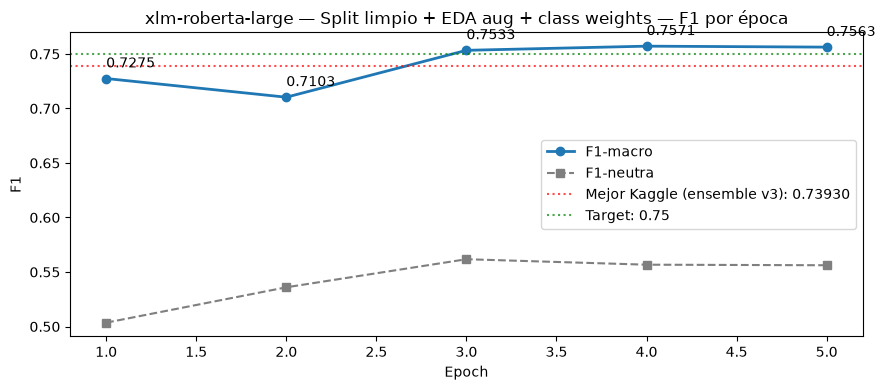

Mejor F1-macro (local, val limpio): 0.7571 en época 4


In [10]:
history  = trainer.state.log_history
eval_f1  = [(x["epoch"], x["eval_f1_macro"]) for x in history if "eval_f1_macro" in x]
eval_neu = [(x["epoch"], x["eval_f1_neu"])   for x in history if "eval_f1_neu"   in x]

fig, ax = plt.subplots(figsize=(9, 4))
if eval_f1:
    epochs, f1s = zip(*eval_f1)
    ax.plot(epochs, f1s, marker="o", label="F1-macro", color="#1f77b4", linewidth=2)
    for e, f in zip(epochs, f1s):
        ax.annotate(f"{f:.4f}", (e, f), textcoords="offset points", xytext=(0, 8))
if eval_neu:
    epochs_n, f1s_n = zip(*eval_neu)
    ax.plot(epochs_n, f1s_n, marker="s", label="F1-neutra", color="#7f7f7f", linestyle="--")

ax.axhline(y=0.73930, color="red", linestyle=":", alpha=0.7, label="Mejor Kaggle (ensemble v3): 0.73930")
ax.axhline(y=0.75,    color="green", linestyle=":", alpha=0.7, label="Target: 0.75")
ax.set_xlabel("Epoch"); ax.set_ylabel("F1")
ax.set_title(f"{MODEL_NAME} — Split limpio + EDA aug + class weights — F1 por época")
ax.legend(); plt.tight_layout(); plt.show()

if eval_f1:
    best_ep, best_f1 = max(eval_f1, key=lambda x: x[1])
    print(f"Mejor F1-macro (local, val limpio): {best_f1:.4f} en época {best_ep:.0f}")

## 9. Guardado del modelo

In [11]:
SAVE_DIR = str(Path("../../../models") / SAVE_NAME)
Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)

trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"Modelo guardado en: {SAVE_DIR}")
print(f"Contenido: {list(Path(SAVE_DIR).iterdir())}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en: ..\..\..\models\red_neuronal_xlm_roberta_n13_large
Contenido: [WindowsPath('../../../models/red_neuronal_xlm_roberta_n13_large/config.json'), WindowsPath('../../../models/red_neuronal_xlm_roberta_n13_large/model.safetensors'), WindowsPath('../../../models/red_neuronal_xlm_roberta_n13_large/tokenizer.json'), WindowsPath('../../../models/red_neuronal_xlm_roberta_n13_large/tokenizer_config.json'), WindowsPath('../../../models/red_neuronal_xlm_roberta_n13_large/training_args.bin')]


## 10. Submission individual (opcional)

Primero se reentrena sobre el dataset completo (train + val) para maximizar el rendimiento en Kaggle.
El modelo del ensemble se carga desde la carpeta guardada arriba (trained on train fold only).

In [12]:
# Reentrenar sobre train + val completo para submission
df_full = pd.concat([
    pd.DataFrame({"text": df_train_final["text"].values, "label": y_train_final}),
    pd.DataFrame({"text": X_val_raw, "label": y_val}),
], ignore_index=True)

X_full = np.array([clean_minimal(t) for t in df_full["text"].values])
y_full = df_full["label"].values.astype(int)

full_dataset = ResenasDataset(X_full, y_full, tokenizer, MAX_LENGTH)

model_full = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, ignore_mismatched_sizes=True,
).to(DEVICE)

training_args_full = TrainingArguments(
    output_dir="./checkpoint_xlm_n13_full",
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    dataloader_num_workers=0,
    dataloader_pin_memory=False,
    learning_rate=LR,
    lr_scheduler_type="cosine",
    warmup_ratio=0.15,
    weight_decay=0.01,
    fp16=USE_FP16,
    logging_steps=50,
    save_strategy="no",
    report_to="none",
    seed=SEED,
)

trainer_full = WeightedTrainer(
    class_weights=CLASS_WEIGHTS,
    model=model_full,
    args=training_args_full,
    train_dataset=full_dataset,
)

print(f"Reentrenando sobre {len(full_dataset):,} muestras (train+val)...")
trainer_full.train()
print("Listo.")

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` ins

Reentrenando sobre 67,000 muestras (train+val)...


Step,Training Loss
50,2.189453
100,2.137809
150,2.098671
200,2.078167
250,1.978280
300,1.985076
350,1.931994
400,1.879336
450,1.836917
500,1.781486


Listo.


In [13]:
Path("submissions").mkdir(exist_ok=True)

preds_test  = trainer_full.predict(test_dataset)
y_test_pred = np.argmax(preds_test.predictions, axis=1)

sub_name = f"submission_{SAVE_NAME}.csv"
sub = pd.DataFrame({"id": test_df["id"].values, "label": y_test_pred.astype(int)})
sub.to_csv(f"submissions/{sub_name}", index=False)

dist = sub["label"].value_counts(normalize=True).sort_index()
print(f"Guardado: submissions/{sub_name} ({len(sub)} predicciones)")
print(f"Distribución: {', '.join(f'clase {k}: {v:.1%}' for k, v in dist.items())}")

Guardado: submissions/submission_red_neuronal_xlm_roberta_n13_large.csv (8500 predicciones)
Distribución: clase 0: 38.2%, clase 1: 23.2%, clase 2: 38.7%
